# Modelagem de Churn — Telecomunicações

**Projeto de Machine Learning · Classificação binária (Churn / Não Churn)**

Pipeline completo de ciência de dados aplicado a uma base de clientes de uma operadora de telecomunicações (internet, telefone e TV): carregamento e limpeza dos dados brutos, análise exploratória, engenharia de atributos, modelagem preditiva (Regressão Logística e Random Forest) e recomendações de negócio para reduzir o cancelamento de clientes.

**Autor:** Talita Luci &nbsp;|&nbsp; [GitHub](https://github.com/TalitaLuci)

---

## Contexto de negócio

Adquirir um cliente novo custa, em média, muito mais do que reter um cliente existente. Para uma operadora de telecom, prever com antecedência **quais clientes têm maior probabilidade de cancelar (churn)** permite agir de forma proativa — com ofertas de retenção direcionadas — em vez de reagir depois que o cliente já cancelou.

## Objetivo

1. Preparar a base bruta de clientes (tipos de dados, valores ausentes, inconsistências de texto).
2. Entender, via análise exploratória, quais variáveis mais se relacionam com o churn.
3. Treinar e comparar modelos de classificação capazes de prever o churn a partir do perfil e do comportamento de contratação do cliente.
4. Traduzir os resultados em recomendações acionáveis para a área de retenção.

## Dados

Base de clientes de uma empresa de telecomunicações, com informações demográficas (gênero, idade, dependentes), serviços contratados (internet, segurança, suporte técnico, streaming), tipo de contrato, forma de pagamento e a variável-alvo `Churn`.

| Arquivo | Descrição |
|---|---|
| `data/raw/CHURN_TELECON.csv` | Base bruta (2.500 registros), com nulos e inconsistências de digitação |

## Resumo dos resultados

*(os números completos, gráficos e métricas de avaliação são gerados ao longo do notebook)*

| Item | Resultado |
|---|---|
| Taxa de churn da base | ~26% dos clientes |
| Modelo final | ver comparação na Seção 8 |
| Principais variáveis preditoras | Tipo de Contrato, Tempo como Cliente, Pagamento Mensal |


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 0

# Caminhos do projeto (funciona abrindo o notebook a partir de notebooks/ ou da raiz)
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_FILE = PROJECT_ROOT / 'data' / 'raw' / 'CHURN_TELECON.csv'


## 1. Carregamento e inspeção dos dados brutos

Começamos pela base bruta, tal como ela chega, sem nenhum tratamento — para documentar exatamente quais problemas de qualidade de dados existem e como cada um foi resolvido.

In [2]:
df = pd.read_csv(DATA_FILE, delimiter=';', encoding='utf-8-sig')
print('Shape:', df.shape)
df.head()

Shape: (2500, 16)


,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes


In [3]:
print('Tipos de dados:')
print(df.dtypes)


Tipos de dados:
customerID                str
Genero                    str
Idoso                   int64
Casado                    str
Dependents                str
Tempo_como_Cliente      int64
PhoneService              str
Servico_Internet          str
Servico_Seguranca         str
Suporte_Tecnico           str
StreamingTV               str
Tipo_Contrato             str
PaymentMethod             str
Pagamento_Mensal      float64
Total_Pago            float64
Churn                     str
dtype: object


**Dicionário de dados (resumo):**

| Coluna | Descrição |
|---|---|
| `customerID` | ID único do cliente |
| `Genero`, `Idoso`, `Casado`, `Dependents` | Perfil demográfico |
| `Tempo_como_Cliente` | Meses de relacionamento com a empresa |
| `PhoneService`, `Servico_Internet`, `Servico_Seguranca`, `Suporte_Tecnico`, `StreamingTV` | Serviços contratados |
| `Tipo_Contrato`, `PaymentMethod` | Condições comerciais |
| `Pagamento_Mensal`, `Total_Pago` | Valores financeiros |
| `Churn` | Variável alvo — o cliente cancelou o serviço? |

Os tipos de dados já estão coerentes com o conteúdo de cada coluna (numéricos como `int`/`float`, categóricos como `object`), então nenhuma conversão de tipo é necessária nesta etapa.

## 2. Pré-processamento

### 2.1 Valores ausentes

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Valores ausentes': missing, '% do total': missing_pct}).query('`Valores ausentes` > 0')


,Valores ausentes,% do total
Genero,12,0.48
PhoneService,1482,59.28
Pagamento_Mensal,325,13.00
Churn,5,0.20


**Estratégia adotada para cada coluna com valores ausentes:**

- **`Churn`** (5 registros, 0,2%) — é a variável alvo do projeto. Sem o rótulo verdadeiro, o registro não pode ser usado nem para treino nem para avaliação de um modelo supervisionado, então essas linhas são **removidas**.
- **`Genero`** (12 registros, 0,48%) — variável categórica com poucos ausentes; será imputada pela **moda** (categoria mais frequente).
- **`Pagamento_Mensal`** (325 registros, 13%) — variável numérica; antes de decidir a estratégia, avaliamos sua distribuição.
- **`PhoneService`** (1.482 registros, ~59%) — mais da metade da coluna está ausente. Imputar um valor para a maioria dos registros introduziria mais ruído do que sinal, então a coluna é **removida** por completo.

> **Importante (evitar vazamento de dados):** a imputação de `Genero` e `Pagamento_Mensal` **não** é feita aqui, sobre a base inteira. Ela é feita dentro da `Pipeline` (Seção 5), de modo que a moda e a mediana sejam calculadas **apenas com os dados de treino**. Nesta seção só removemos o que não pode ser usado (alvo ausente e coluna com ~59% de nulos).

In [5]:
df = df.dropna(subset=['Churn']).reset_index(drop=True)
print('Registros após remover alvo ausente:', len(df))

Registros após remover alvo ausente: 2495


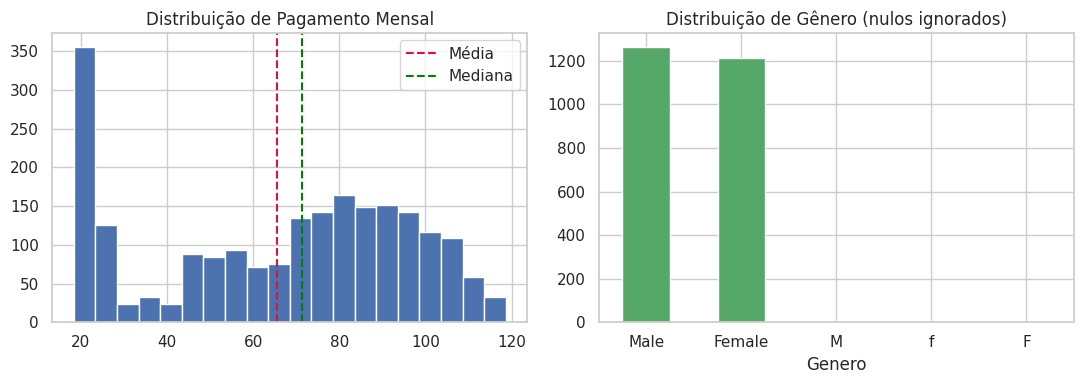

Média: 65.61
Mediana: 71.45


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df['Pagamento_Mensal'].hist(ax=axes[0], bins=20, color='#4C72B0')
axes[0].axvline(df['Pagamento_Mensal'].mean(), color='crimson', linestyle='--', label='Média')
axes[0].axvline(df['Pagamento_Mensal'].median(), color='green', linestyle='--', label='Mediana')
axes[0].set_title('Distribuição de Pagamento Mensal')
axes[0].legend()

df['Genero'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Distribuição de Gênero (nulos ignorados)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('Média:', round(df['Pagamento_Mensal'].mean(), 2))
print('Mediana:', round(df['Pagamento_Mensal'].median(), 2))


A distribuição de `Pagamento_Mensal` **não é simétrica**: a mediana (≈ 71) é bem maior que a média (≈ 66), porque há um grupo grande de clientes com mensalidade baixa (provavelmente quem não contrata internet), formando um segundo pico à esquerda. Nesse caso a **mediana** é a medida mais robusta, e é ela que será usada para imputar os valores ausentes — dentro da `Pipeline`, calculada só no treino.

In [7]:
df = df.drop(columns=['PhoneService'])

print('Valores ausentes restantes (serão imputados dentro da Pipeline):')
print(df.isnull().sum()[lambda s: s > 0].to_string())

Valores ausentes restantes (serão imputados dentro da Pipeline):
Genero                7
Pagamento_Mensal    320


### 2.2 Inconsistências de digitação

Categorias iguais escritas de formas diferentes (maiúsculas/minúsculas, abreviações) inflam artificialmente o número de categorias e prejudicam qualquer análise ou modelo. Verificamos e padronizamos as colunas categóricas relevantes.

In [8]:
print('Valores únicos em Genero antes da padronização:', df['Genero'].unique())
print('Valores únicos em Servico_Internet antes da padronização:', df['Servico_Internet'].unique())

df['Genero'] = df['Genero'].replace({'F': 'Female', 'f': 'Female', 'M': 'Male'})
df['Servico_Internet'] = df['Servico_Internet'].replace({'dsl': 'DSL'})

print()
print('Valores únicos em Genero depois:', df['Genero'].unique())
print('Valores únicos em Servico_Internet depois:', df['Servico_Internet'].unique())


Valores únicos em Genero antes da padronização: <StringArray>
['Female', 'Male', nan, 'F', 'M', 'f']
Length: 6, dtype: str
Valores únicos em Servico_Internet antes da padronização: <StringArray>
['DSL', 'Fiber optic', 'dsl', 'No']
Length: 4, dtype: str

Valores únicos em Genero depois: <StringArray>
['Female', 'Male', nan]
Length: 3, dtype: str
Valores únicos em Servico_Internet depois: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


### 2.3 Padronização de nomes de colunas

As colunas originais misturam português e inglês (`Genero`, `PhoneService`, `StreamingTV`...). Padronizamos tudo em português para manter consistência ao longo do projeto.

In [9]:
df.columns = [
    'Cliente_ID', 'Genero', 'Idoso', 'Casado', 'Dependentes', 'Tempo_Cliente',
    'Servico_Internet', 'Servico_Seguranca', 'Suporte_Tecnico', 'Streaming_TV',
    'Tipo_Contrato', 'Forma_Pagamento', 'Pagamento_Mensal', 'Total_Pago', 'Churn'
]
print('Shape final após limpeza:', df.shape)
df.head()


Shape final após limpeza: (2495, 15)


,Cliente_ID,Genero,Idoso,Casado,Dependentes,Tempo_Cliente,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,Streaming_TV,Tipo_Contrato,Forma_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes


## 3. Análise exploratória — univariada

### 3.1 Estatísticas descritivas e outliers

In [10]:
df.describe()


,Idoso,Tempo_Cliente,Pagamento_Mensal,Total_Pago
count,2495.000000,2495.000000,2175.000000,2495.000000
mean,0.161122,32.354309,65.607563,2292.625812
std,0.367717,24.634007,29.931520,2266.888527
min,0.000000,0.000000,18.400000,18.800000
25%,0.000000,8.000000,39.500000,402.175000
50%,0.000000,29.000000,71.450000,1404.650000
75%,0.000000,56.000000,90.250000,3874.750000
max,1.000000,72.000000,118.650000,8564.750000


In [11]:
colunas_numericas = ['Idoso', 'Tempo_Cliente', 'Pagamento_Mensal', 'Total_Pago']

for coluna in colunas_numericas:
    Q1, Q3 = df[coluna].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    limite_inf, limite_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[coluna] < limite_inf) | (df[coluna] > limite_sup)]
    print(f'{coluna:18s} → {len(outliers)} possíveis outliers (limites: {limite_inf:.1f} a {limite_sup:.1f})')


Idoso              → 402 possíveis outliers (limites: 0.0 a 0.0)
Tempo_Cliente      → 0 possíveis outliers (limites: -64.0 a 128.0)
Pagamento_Mensal   → 0 possíveis outliers (limites: -36.6 a 166.4)
Total_Pago         → 0 possíveis outliers (limites: -4806.7 a 9083.6)


**Leitura:** `Idoso` é uma variável binária (0/1), então o método IQR naturalmente marca os "1" como outlier — isso não é um problema de qualidade de dado, apenas uma limitação do método para variáveis binárias, e é ignorado. Nas demais variáveis, os valores fora do intervalo IQR são consistentes com o negócio (clientes de longa data com pagamento acumulado alto, planos mais caros com mais serviços) e não indicam erro de digitação ou medição — por isso nenhum outlier é removido.

Como checagem adicional, comparamos `Total_Pago` com o valor esperado (`Pagamento_Mensal × Tempo_Cliente`):

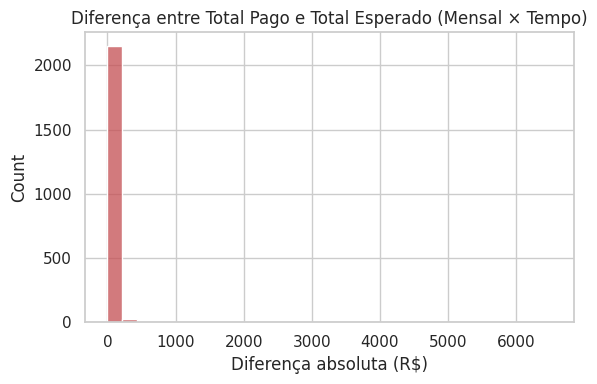

Diferença mediana: 28.1


In [12]:
df['Total_Esperado'] = df['Pagamento_Mensal'] * df['Tempo_Cliente']
diff = (df['Total_Esperado'] - df['Total_Pago']).abs()

plt.figure(figsize=(6, 4))
sns.histplot(diff, bins=30, color='#C44E52')
plt.title('Diferença entre Total Pago e Total Esperado (Mensal × Tempo)')
plt.xlabel('Diferença absoluta (R$)')
plt.tight_layout()
plt.show()

print('Diferença mediana:', round(diff.median(), 2))
df = df.drop(columns=['Total_Esperado'])


Existe diferença entre o valor total pago e o valor "esperado" (mensalidade atual × tempo de contrato), o que é normal em bases de telecom reais: o valor da mensalidade muda ao longo do tempo (upgrades de plano, promoções, reajustes), então multiplicar a mensalidade *atual* pelo tempo total não reflete o histórico de cobrança. Não é um erro de dado a ser corrigido — é uma limitação conhecida da variável, registrada aqui para transparência.

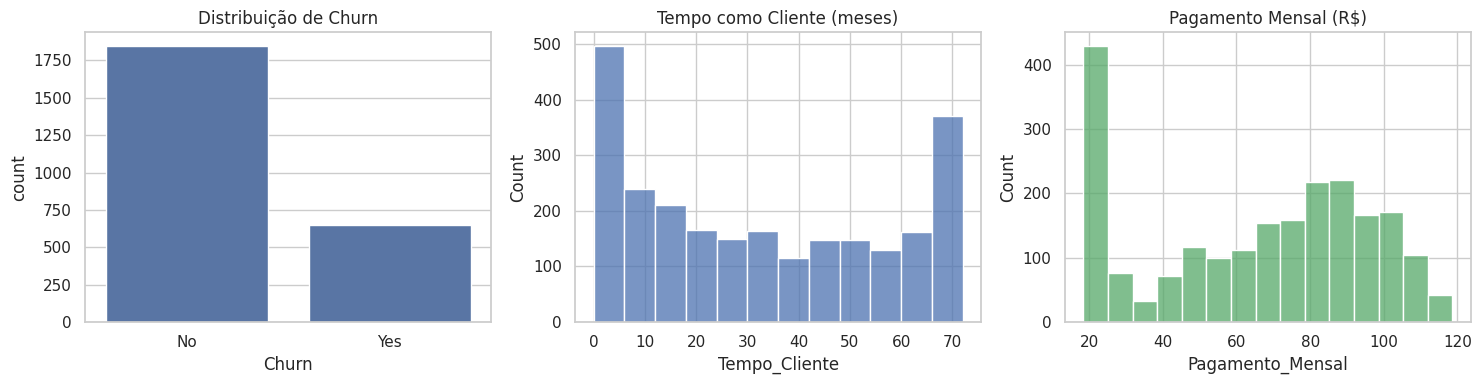

Taxa de churn da base: 26.0%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='Churn', ax=axes[0], order=['No', 'Yes'])
axes[0].set_title('Distribuição de Churn')

sns.histplot(df['Tempo_Cliente'], bins=12, ax=axes[1], color='#4C72B0')
axes[1].set_title('Tempo como Cliente (meses)')

sns.histplot(df['Pagamento_Mensal'], bins=15, ax=axes[2], color='#55A868')
axes[2].set_title('Pagamento Mensal (R$)')

plt.tight_layout()
plt.show()

churn_rate = (df['Churn'] == 'Yes').mean()
print(f'Taxa de churn da base: {churn_rate:.1%}')


**Leitura:**
- A base tem uma taxa de churn de aproximadamente 26% — desbalanceada, como é típico em problemas de churn (a maioria dos clientes permanece). Isso é levado em conta na modelagem (Seção 7).
- `Tempo_Cliente` tem dois grupos concentrados: clientes muito novos (até 5 meses) e clientes muito antigos (65+ meses) — sugerindo que quem passa da fase inicial tende a ficar por muito tempo.
- `Pagamento_Mensal` tem dois grupos: um pico de mensalidades baixas (provavelmente clientes sem internet) e uma massa maior entre ~70 e ~100, sem valores extremos isolados.

In [14]:
bool_cols = ['Idoso', 'Genero', 'Casado', 'Dependentes', 'Churn']
for c in bool_cols:
    print(f'--- {c} ---')
    print(df[c].value_counts(normalize=True).round(3))
    print()


--- Idoso ---
Idoso
0    0.839
1    0.161
Name: proportion, dtype: float64

--- Genero ---
Genero
Male      0.51
Female    0.49
Name: proportion, dtype: float64

--- Casado ---
Casado
No     0.507
Yes    0.493
Name: proportion, dtype: float64

--- Dependentes ---
Dependentes
No     0.685
Yes    0.315
Name: proportion, dtype: float64

--- Churn ---
Churn
No     0.74
Yes    0.26
Name: proportion, dtype: float64



`Idoso` (16% sim) e `Dependentes` (31% sim) são desbalanceadas, o que é esperado no perfil de clientes de uma base residencial. `Churn` também é desbalanceada (26% sim), reforçando a necessidade de tratar esse desbalanceamento na modelagem.

## 4. Análise exploratória — bivariada

Investigamos cinco perguntas de negócio diretamente ligadas ao churn.

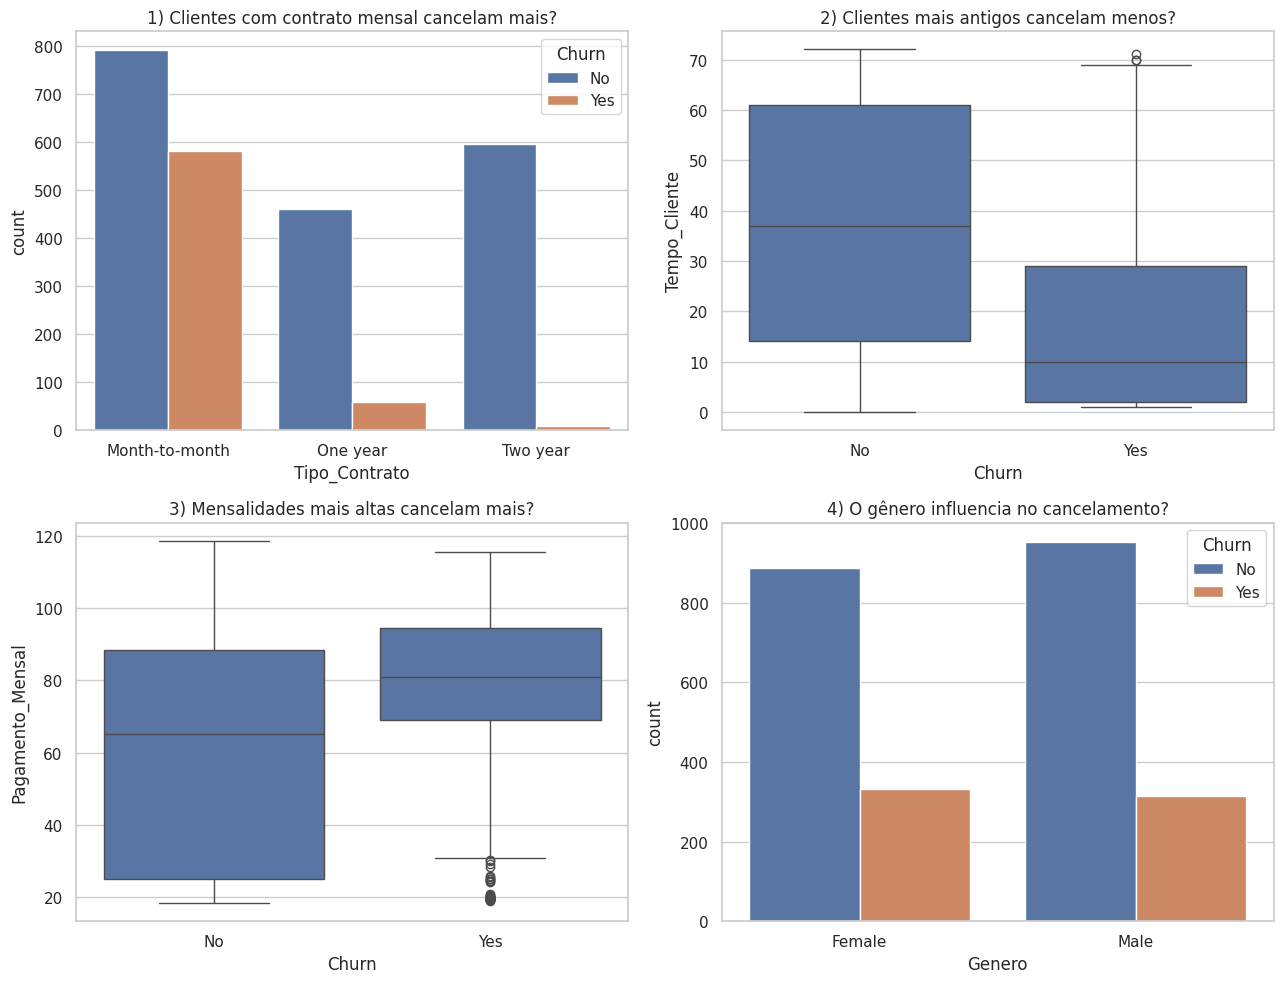

In [15]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.countplot(data=df, x='Tipo_Contrato', hue='Churn', ax=axes[0, 0])
axes[0, 0].set_title('1) Clientes com contrato mensal cancelam mais?')

sns.boxplot(data=df, x='Churn', y='Tempo_Cliente', ax=axes[0, 1])
axes[0, 1].set_title('2) Clientes mais antigos cancelam menos?')

sns.boxplot(data=df, x='Churn', y='Pagamento_Mensal', ax=axes[1, 0])
axes[1, 0].set_title('3) Mensalidades mais altas cancelam mais?')

sns.countplot(data=df, x='Genero', hue='Churn', ax=axes[1, 1])
axes[1, 1].set_title('4) O gênero influencia no cancelamento?')

plt.tight_layout()
plt.show()


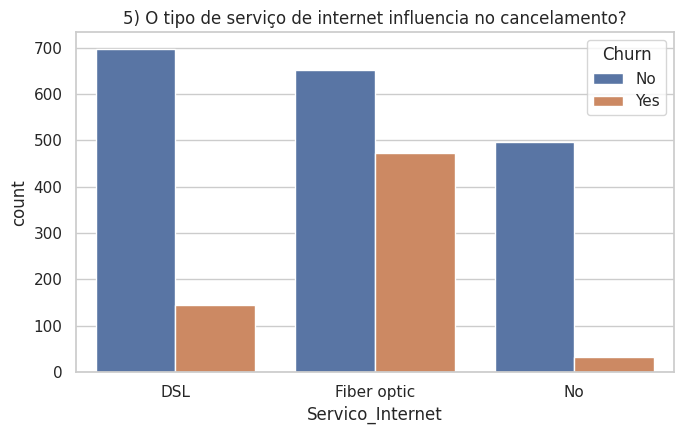

In [16]:
plt.figure(figsize=(7, 4.5))
sns.countplot(data=df, x='Servico_Internet', hue='Churn')
plt.title('5) O tipo de serviço de internet influencia no cancelamento?')
plt.tight_layout()
plt.show()


In [17]:
from scipy.stats import chi2_contingency

churn_bin = (df['Churn'] == 'Yes').astype(int)
print('Taxa de churn por gênero:')
print(churn_bin.groupby(df['Genero']).mean().round(3).to_string())
chi2, p_value, _, _ = chi2_contingency(pd.crosstab(df['Genero'], churn_bin))
print(f'\nQui-quadrado (gênero x churn): p-valor = {p_value:.3f}  ->  diferença {"significativa" if p_value < 0.05 else "NÃO significativa"} a 5%')

Taxa de churn por gênero:
Genero
Female    0.272
Male      0.248

Qui-quadrado (gênero x churn): p-valor = 0.185  ->  diferença NÃO significativa a 5%


**Respostas:**

1. **Sim.** Contratos mensais concentram a grande maioria dos cancelamentos; contratos de 1 e 2 anos têm churn muito baixo — o principal alavancador de retenção identificado na base.
2. **Sim.** Clientes que cancelam têm, em mediana, muito menos tempo de casa — o risco de churn é maior nos primeiros meses de relacionamento.
3. **Sim.** Quem cancela paga, em mediana, mensalidades mais altas — sugere que o preço percebido pode não estar alinhado ao valor entregue nesses planos.
4. **Não de forma relevante.** A diferença de churn entre os gêneros é pequena e não é estatisticamente significativa (teste qui-quadrado na célula acima).
5. **Sim, parcialmente.** Clientes com internet fibra ótica têm taxa de churn visivelmente maior que DSL ou sem internet — possível indício de problema de qualidade/preço nesse serviço específico.

Com base nesta análise, as variáveis mais relevantes para prever churn são **Tipo_Contrato**, **Tempo_Cliente**, **Pagamento_Mensal** e **Servico_Internet**. Testamos essa hipótese formalmente na modelagem a seguir.

## 5. Engenharia de atributos

Preparamos os dados para a modelagem:
- Removemos `Cliente_ID` (identificador, sem valor preditivo) e `Total_Pago`. O `Total_Pago` **não** é vazamento do alvo; ele foi excluído por ser praticamente redundante: sua correlação com `Pagamento_Mensal × Tempo_Cliente` é de ≈ 0,998, ou seja, repete informação que já entra no modelo via `Tempo_Cliente` e `Pagamento_Mensal`. Testado em validação cruzada, incluí-lo muda o ROC-AUC em apenas ~+0,002 (Regressão Logística) a +0,006 (Random Forest).
- Codificamos a variável alvo `Churn` como binária (1 = cancelou).
- Montamos um `ColumnTransformer` com **imputação + padronização** nas numéricas (mediana → `StandardScaler`) e **imputação + one-hot** nas categóricas (moda → `OneHotEncoder`), empacotado junto ao modelo em uma `Pipeline` — assim imputação, escala e codificação são ajustadas apenas nos dados de treino (e refeitas dentro de cada fold da validação cruzada), evitando vazamento de informação do teste.

In [18]:
df_model = df.drop(columns=['Cliente_ID', 'Total_Pago']).copy()
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

numeric_features = ['Idoso', 'Tempo_Cliente', 'Pagamento_Mensal']
categorical_features = [c for c in X.columns if c not in numeric_features]

print('Variáveis numéricas:', numeric_features)
print('Variáveis categóricas:', categorical_features)

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

Variáveis numéricas: ['Idoso', 'Tempo_Cliente', 'Pagamento_Mensal']
Variáveis categóricas: ['Genero', 'Casado', 'Dependentes', 'Servico_Internet', 'Servico_Seguranca', 'Suporte_Tecnico', 'Streaming_TV', 'Tipo_Contrato', 'Forma_Pagamento']


## 6. Separação treino / teste

Usamos separação estratificada para manter a mesma proporção de churn em treino e teste, essencial em um problema desbalanceado como este.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('Treino:', X_train.shape, '| Taxa de churn:', y_train.mean().round(3))
print('Teste :', X_test.shape, ' | Taxa de churn:', y_test.mean().round(3))


Treino: (1996, 12) | Taxa de churn: 0.26
Teste : (499, 12)  | Taxa de churn: 0.261


## 7. Modelagem

Treinamos e comparamos dois modelos:

- **Regressão Logística** — modelo linear, rápido e interpretável (bom ponto de partida e baseline de negócio).
- **Random Forest** — modelo não linear, geralmente mais robusto a interações entre variáveis.

Ambos usam `class_weight='balanced'` para compensar o desbalanceamento das classes sem precisar re-amostrar os dados.

In [20]:
models = {
    'Regressão Logística': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE
    ),
}

pipelines = {}
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f'{name}: treinado.')


Regressão Logística: treinado.


Random Forest: treinado.


### 7.1 Validação cruzada (treino)

Antes de olhar para o teste, checamos a estabilidade de cada modelo com validação cruzada estratificada de 5 folds, usando ROC-AUC — métrica mais informativa que acurácia em problemas desbalanceados.

In [21]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='roc_auc')
    print(f'{name:22s} ROC-AUC (5-fold CV): {scores.mean():.4f} ± {scores.std():.4f}')


Regressão Logística    ROC-AUC (5-fold CV): 0.8442 ± 0.0148


Random Forest          ROC-AUC (5-fold CV): 0.8157 ± 0.0222


## 8. Avaliação no conjunto de teste

In [22]:
results = []
roc_data = {}

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão (Churn)': precision_score(y_test, y_pred),
        'Recall (Churn)': recall_score(y_test, y_pred),
        'F1 (Churn)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })
    roc_data[name] = roc_curve(y_test, y_proba)

results_df = pd.DataFrame(results).set_index('Modelo').round(4)
results_df


,Acurácia,Precisão (Churn),Recall (Churn),F1 (Churn),ROC-AUC
Modelo,,,,,
Regressão Logística,0.7635,0.5278,0.8769,0.6590,0.8737
Random Forest,0.7876,0.5952,0.5769,0.5859,0.8456


**Por que olhar além da acurácia:** como só ~26% dos clientes cancelam, um modelo "preguiçoso" que sempre previsse "não cancela" já acertaria ~74% — e seria inútil para o negócio. Por isso priorizamos **Recall da classe Churn** (quantos cancelamentos reais o modelo consegue capturar) e **ROC-AUC** (capacidade geral de separar as duas classes), que são muito mais relevantes aqui do que a acurácia isolada.

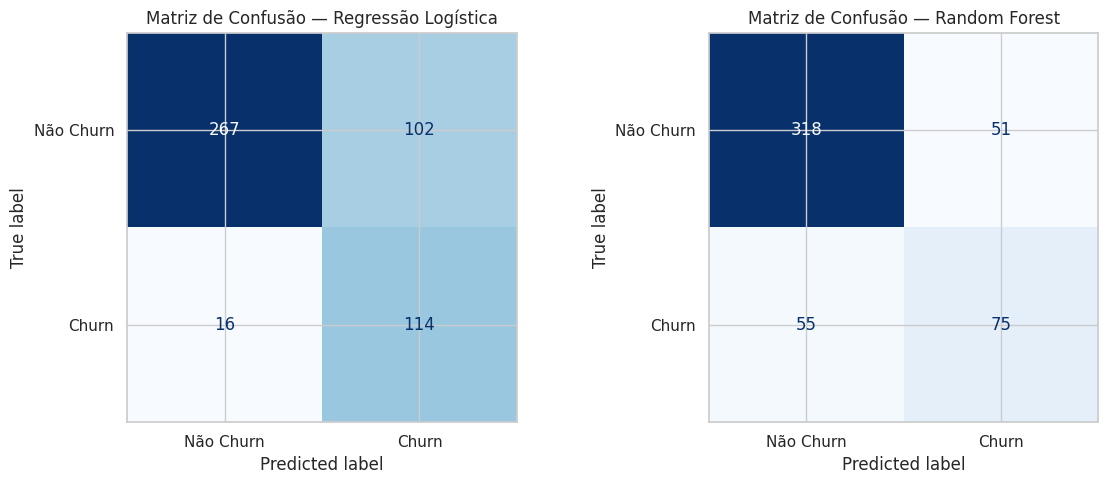

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Não Churn', 'Churn']).plot(
        ax=axes[0] if name == 'Regressão Logística' else axes[1], cmap='Blues', colorbar=False
    )
    (axes[0] if name == 'Regressão Logística' else axes[1]).set_title(f'Matriz de Confusão — {name}')

plt.tight_layout()
plt.show()


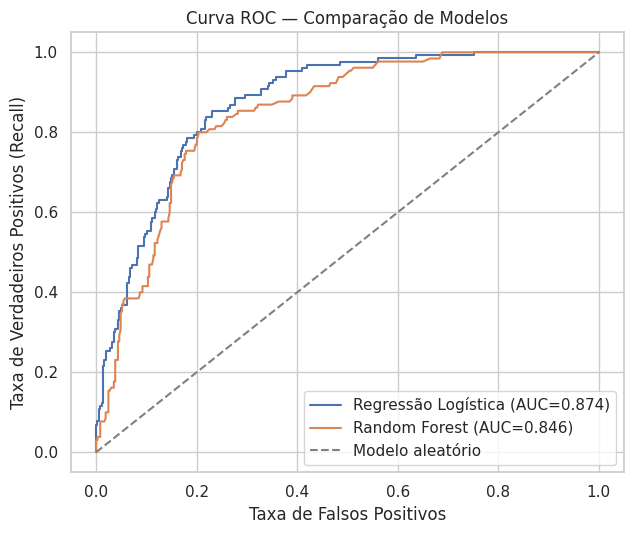

In [24]:
plt.figure(figsize=(6.5, 5.5))
for name, (fpr, tpr, _) in roc_data.items():
    auc = results_df.loc[name, 'ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC — Comparação de Modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Leitura:** ambos os modelos superam claramente um classificador aleatório. Comparamos os dois pelo ROC-AUC e pelo recall da classe Churn — o critério de escolha final depende do apetite de negócio: um recall mais alto significa capturar mais clientes em risco (mesmo que isso gere algumas ações de retenção "desnecessárias" em clientes que não cancelariam), o que costuma valer a pena quando o custo de uma ação de retenção é bem menor que o custo de perder o cliente.

## 9. Quais variáveis mais pesam na decisão do modelo?

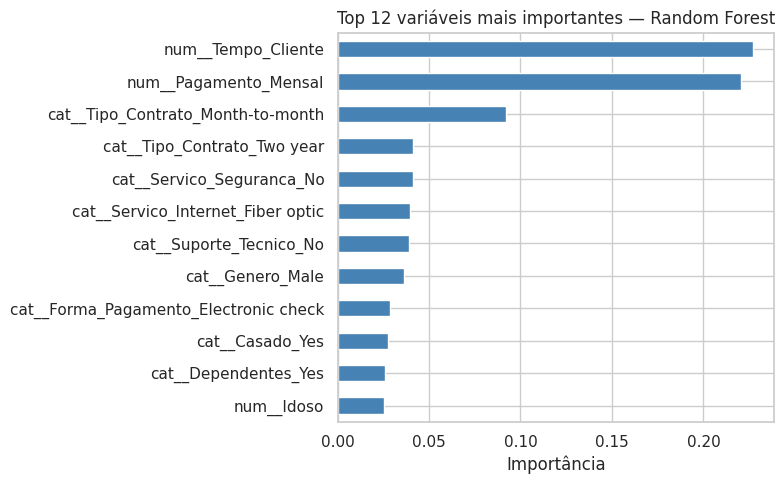

In [25]:
rf_pipe = pipelines['Random Forest']
feature_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = pd.Series(
    rf_pipe.named_steps['model'].feature_importances_, index=feature_names
).sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5))
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 12 variáveis mais importantes — Random Forest')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()


**Leitura:** as variáveis no topo do ranking confirmam a hipótese levantada na análise bivariada (Seção 4) — tipo de contrato, tempo como cliente e pagamento mensal estão entre as mais relevantes para o modelo, junto com o tipo de serviço de internet. Isso dá confiança de que o modelo está aprendendo padrões consistentes com o que a análise exploratória já indicava, e não ruído.

**Ressalva:** a importância por impureza do Random Forest tende a favorecer variáveis contínuas (`Tempo_Cliente`, `Pagamento_Mensal`) e pode atribuir alguma importância a variáveis sem efeito real — por exemplo, `Genero` aparece no ranking mesmo sem relação significativa com o churn. Por isso o ranking deve ser lido como indicação geral, e não como medida exata de causalidade.

## 10. Conclusões, limitações e próximos passos

**Principais conclusões**
- A base tem taxa de churn de ~26%, concentrada fortemente em clientes com **contrato mensal**, **pouco tempo de casa** e **mensalidades mais altas** — três alavancas de negócio claras para uma estratégia de retenção.
- Os modelos treinados (Regressão Logística e Random Forest) conseguem separar clientes em risco de churn de forma consistentemente melhor que o acaso, com as variáveis mais importantes batendo com os achados da análise exploratória.
- O gênero do cliente não tem relação relevante com o churn, então não deveria compor nenhuma régua de priorização de retenção.

**Recomendações de negócio**
- Priorizar ofertas de migração de contrato mensal para planos anuais/bianuais, especialmente para clientes nos primeiros meses de relacionamento.
- Investigar a experiência de clientes com internet fibra ótica e mensalidades mais altas, onde o churn é maior — pode indicar descompasso entre preço e percepção de valor.
- Usar a probabilidade de churn do modelo para priorizar contato proativo da equipe de retenção com os clientes de maior risco, em vez de campanhas genéricas.

**Limitações**
- A base é de um único período (sem histórico temporal), então o modelo não captura tendências ou sazonalidade do churn ao longo do tempo.
- `Total_Pago` foi removido da modelagem por ser redundante com `Pagamento_Mensal × Tempo_Cliente` (ganho de ROC-AUC de ~0,002 a 0,006 ao incluí-lo); vale reavaliar com engenharia de atributos mais cuidadosa (ex.: valor médio pago por mês) em uma iteração futura.

**Próximos passos sugeridos**
- Testar modelos adicionais (Gradient Boosting/XGBoost) e ajuste fino de hiperparâmetros via `GridSearchCV`/`RandomizedSearchCV`.
- Calibrar o ponto de corte de decisão (threshold) de acordo com o custo real de uma ação de retenção vs. o custo de perder o cliente, em vez de usar o padrão de 0,5.
- Validar o modelo com dados mais recentes antes de qualquer uso em produção, e reavaliar periodicamente (o comportamento de churn tende a mudar com o tempo).
